In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

from src.data_processing import clean_text
from src.features import Vocabulary, texts_to_sequences, TextDataset
from torch.utils.data import DataLoader

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(sorted(df['Label'].unique()))}
idx_to_label = {v: k for k, v in label_map.items()}
NUM_CLASSES = len(label_map)
print(f"Classes ({NUM_CLASSES}): {label_map}")

df['label_id']   = df['Label'].map(label_map)
df['text_clean'] = df['Text'].apply(clean_text)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

vocab = Vocabulary(max_words=20000)
vocab.fit(X_train_raw.tolist())

MAX_LEN = 200
BATCH_SIZE = 64

X_train_seq = texts_to_sequences(X_train_raw.tolist(), vocab, max_len=MAX_LEN)
X_val_seq   = texts_to_sequences(X_val_raw.tolist(),   vocab, max_len=MAX_LEN)
Y_train, Y_val = np.array(y_train), np.array(y_val)

train_loader = DataLoader(TextDataset(X_train_seq, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val_seq,   Y_val),   batch_size=BATCH_SIZE, shuffle=False)

os.makedirs("../submissions/submissao1", exist_ok=True)
vocab.save("../submissions/submissao1/vocab.pkl")
print(f"Vocabulário: {len(vocab)} palavras | Treino: {X_train_seq.shape} | Val: {X_val_seq.shape}")

Classes (6): {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'Mistral': 4, 'OpenAI': 5}
Vocabulário: 19237 palavras | Treino: (4108, 200) | Val: (1028, 200)


In [3]:
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def train_model(model, train_loader, val_loader, epochs, lr=1e-3, verbose=True):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = eval_epoch(model,  val_loader,   criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"Epoch {epoch:>3}/{epochs} | Loss Treino: {tr_loss:.4f} | Loss Val: {vl_loss:.4f} | "
                  f"Acc Treino: {tr_acc:.3f} | Acc Val: {vl_acc:.3f}")
    return history

Device: cpu


In [ ]:
# from src.models_pytorch.cnn1d import CNN1DClassifier
# import copy
#
# EPOCH_CANDIDATES = [5, 10, 20, 30, 50]
# epoch_results = []
#
# for n_epochs in EPOCH_CANDIDATES:
#     print(f"\n==================================================")
#     print(f"A testar: {n_epochs} epochs")
#     print('='*50)
#     model_tmp = CNN1DClassifier(**dict(vocab_size=len(vocab), embedding_dim=100, n_filters=100, filter_sizes=[2,3,4], output_dim=NUM_CLASSES, dropout=0.3))
#     hist = train_model(model_tmp, train_loader, val_loader, epochs=n_epochs, verbose=True)
#     best_acc  = max(hist["val_acc"])
#     best_loss = min(hist["val_loss"])
#     epoch_results.append((n_epochs, best_acc, best_loss))
#     print(f"  \u2192 Melhor Val Acc: {best_acc:.4f} | Melhor Val Loss: {best_loss:.4f}")
#
# fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# epochs_list = [r[0] for r in epoch_results]
# accs        = [r[1] for r in epoch_results]
# losses      = [r[2] for r in epoch_results]
#
# axes[0].bar([str(e) for e in epochs_list], accs,   color='steelblue')
# axes[0].set_title("Melhor Val Accuracy por N\u00ba de Epochs")
# axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Accuracy")
# for i, v in enumerate(accs):
#     axes[0].text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=9)
#
# axes[1].bar([str(e) for e in epochs_list], losses, color='coral')
# axes[1].set_title("Melhor Val Loss por N\u00ba de Epochs")
# axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Loss")
# for i, v in enumerate(losses):
#     axes[1].text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=9)
#
# plt.suptitle("CNN1DClassifier \u2014 Pesquisa de Epochs", fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()
#
# BEST_EPOCHS = epoch_results[accs.index(max(accs))][0]
# print(f"\nMelhor n\u00famero de epochs: {BEST_EPOCHS} (Val Acc: {max(accs):.4f})")

Epoch   1/50 | Loss Treino: 1.4566 | Loss Val: 0.9215 | Acc Treino: 0.420 | Acc Val: 0.740
Epoch   5/50 | Loss Treino: 0.3781 | Loss Val: 0.3275 | Acc Treino: 0.870 | Acc Val: 0.904
Epoch  10/50 | Loss Treino: 0.1817 | Loss Val: 0.2085 | Acc Treino: 0.941 | Acc Val: 0.929
Epoch  15/50 | Loss Treino: 0.1189 | Loss Val: 0.1787 | Acc Treino: 0.961 | Acc Val: 0.939
Epoch  20/50 | Loss Treino: 0.0641 | Loss Val: 0.2036 | Acc Treino: 0.983 | Acc Val: 0.928
Epoch  25/50 | Loss Treino: 0.0618 | Loss Val: 0.1698 | Acc Treino: 0.981 | Acc Val: 0.945
Epoch  30/50 | Loss Treino: 0.0540 | Loss Val: 0.1666 | Acc Treino: 0.982 | Acc Val: 0.944
Epoch  35/50 | Loss Treino: 0.0370 | Loss Val: 0.1949 | Acc Treino: 0.986 | Acc Val: 0.941
Epoch  40/50 | Loss Treino: 0.0359 | Loss Val: 0.1635 | Acc Treino: 0.988 | Acc Val: 0.951
Epoch  45/50 | Loss Treino: 0.0294 | Loss Val: 0.1978 | Acc Treino: 0.990 | Acc Val: 0.944
Epoch  50/50 | Loss Treino: 0.0239 | Loss Val: 0.1939 | Acc Treino: 0.993 | Acc Val: 0.946

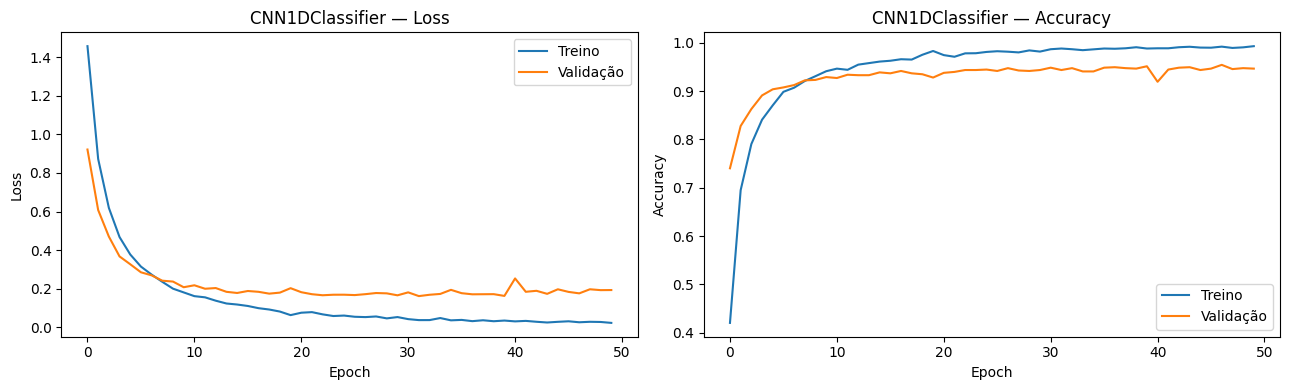


Modelo guardado em ../submissions/submissao2/cnn1d_weights.pt


In [ ]:
from src.models_pytorch.cnn1d import CNN1DClassifier

EPOCHS = 50
model = CNN1DClassifier(**dict(vocab_size=len(vocab), embedding_dim=100, n_filters=100, filter_sizes=[2,3,4], output_dim=NUM_CLASSES, dropout=0.3))
history = train_model(model, train_loader, val_loader, epochs=EPOCHS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="Treino")
axes[0].plot(history["val_loss"],   label="Valida\u00e7\u00e3o")
axes[0].set_title("CNN1DClassifier \u2014 Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Treino")
axes[1].plot(history["val_acc"],   label="Valida\u00e7\u00e3o")
axes[1].set_title("CNN1DClassifier \u2014 Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout(); plt.show()

torch.save(model.state_dict(), "../submissions/submissao1/cnn1d_weights.pt")
print("\nModelo guardado em ../submissions/submissao1/cnn1d_weights.pt")

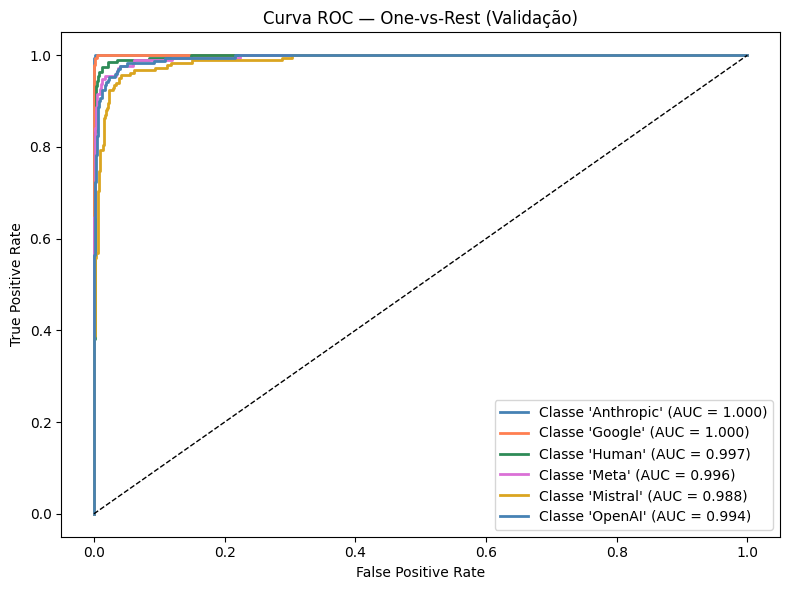

In [5]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch.to(DEVICE))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.numpy())

all_probs  = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

classes    = list(range(NUM_CLASSES))
labels_bin = label_binarize(all_labels, classes=classes)

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen', 'orchid', 'goldenrod']

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    class_name  = idx_to_label[i]
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
             label=f"Classe '{class_name}' (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC \u2014 One-vs-Rest (Valida\u00e7\u00e3o)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [6]:
print("Melhor Val Accuracy CNN1D:", max(history["val_acc"]))
print("Melhor Val Loss CNN1D:", min(history["val_loss"]))

Melhor Val Accuracy CNN1D: 0.9542801556420234
Melhor Val Loss CNN1D: 0.16251303580932044


In [7]:
import os
import torch
os.makedirs("../submissions/submissao1", exist_ok=True)
torch.save(model.state_dict(), "../submissions/submissao1/cnn1d_weights.pt")
vocab.save("../submissions/submissao1/vocab.pkl")
print("Artefactos CNN1D guardados em ../submissions/submissao1/")

Artefactos CNN1D guardados em ../submissions/submissao1/
